# Projeto EDA - Classificação do perfil de investimento

Projeto de **EDA**, de Análise Exploratória de Dados (EDA).

## Objetivo

Investigar se características observadas na composição da carteira de cada cliente estão associadas ao perfil operativo registrado na política de investimento.

A tarefa é de classificação, com três possíveis classes:

- Conservadora
- Moderada
- Sofisticada

O alvo utilizado será `investmentPolicy`.

Nesta etapa o objetivo é:

1. conhecer e avaliar a qualidade dos dados;
2. realizar análises univariadas e bivariadas;
3. identificar riscos para a futura modelagem;
4. decidir estratégias de pré-processamento;
5. produzir PCA, t-SNE e UMAP;
6. entregar um pipeline de pré-processamento pronto para a etapa seguinte.

Todas as operações que possuem `random_state` utilizarão:

`random_state = 42`

## Decisões gerais do projeto

Os dados estão divididos em três fontes:

- `clientes_wallet_distribution.json`: composição observada das carteiras;
- `clientes_investment_policy.json`: política de investimento e origem do alvo;
- `account.json`: informações cadastrais.

A variável `accountCode` será utilizada apenas para fazer os cruzamentos entre as fontes e será removida antes da preparação dos dados para modelagem.

A policy será utilizada **somente para recuperar o alvo `investmentPolicy`**.

Campos como bandas recomendadas, gaps, enquadramento, risco, limite e demais informações calculadas a partir da própria policy não serão utilizados como features, pois poderiam introduzir vazamento do alvo.

O campo cadastral `dscSuitability` também não será utilizado como entrada do modelo.

A principal feature categórica proveniente do cadastro será `personType`.

In [2]:
%pip install -q scikit-learn umap-learn seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\usuario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 0. Configuração

In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

### Caminhos dos arquivos

No repositório final, os arquivos devem ficar na pasta `Dados/`.

O fallback com nomes terminados em `(2)` existe apenas porque os arquivos enviados para análise receberam esse nome.

In [4]:
DATA_DIR = Path("Dados")

# Fallback para o ambiente em que os arquivos enviados estão armazenados.
if not DATA_DIR.exists():
    DATA_DIR = Path("/mnt/data/eda_inputs")


def localizar_arquivo(nome_repositorio, nome_upload):
    arquivo_normal = DATA_DIR / nome_repositorio
    arquivo_upload = DATA_DIR / nome_upload

    if arquivo_normal.exists():
        return arquivo_normal

    if arquivo_upload.exists():
        return arquivo_upload

    raise FileNotFoundError(
        f"Não foi encontrado nem {arquivo_normal} nem {arquivo_upload}"
    )


ACCOUNT_PATH = localizar_arquivo(
    "account.json",
    "account(2).json"
)

POLICY_PATH = localizar_arquivo(
    "clientes_investment_policy.json",
    "clientes_investment_policy(2).json"
)

WALLET_PATH = localizar_arquivo(
    "clientes_wallet_distribution.json",
    "clientes_wallet_distribution(2).json"
)

# 1. Inspeção inicial

## 1A. Origem e construção do dataset analítico

A unidade observacional do dataset final será **uma conta de cliente**.

Cada linha conterá características agregadas da composição atual da carteira e o perfil operativo registrado na policy.

Como o arquivo da wallet é muito grande, ele será lido de maneira incremental para evitar carregar todo o JSON de uma vez na memória.

In [5]:
def stream_json_array(path, chunk_size=1024 * 1024):
    """
    Leitura incremental de um JSON cujo nível superior é uma lista.
    Evita carregar a wallet inteira na memória.
    """
    decoder = json.JSONDecoder()

    with open(path, "r", encoding="utf-8") as arquivo:
        buffer = ""
        iniciou_lista = False
        fim_arquivo = False

        while True:
            if not fim_arquivo and len(buffer) < chunk_size:
                trecho = arquivo.read(chunk_size)
                if trecho:
                    buffer += trecho
                else:
                    fim_arquivo = True

            buffer = buffer.lstrip()

            if not iniciou_lista:
                if not buffer:
                    if fim_arquivo:
                        return
                    continue

                if buffer[0] != "[":
                    raise ValueError(
                        "O JSON de nível superior deve ser uma lista."
                    )

                buffer = buffer[1:]
                iniciou_lista = True
                continue

            if buffer.startswith(","):
                buffer = buffer[1:].lstrip()

            if buffer.startswith("]"):
                return

            if not buffer:
                if fim_arquivo:
                    return
                continue

            try:
                item, indice = decoder.raw_decode(buffer)
            except json.JSONDecodeError:
                if fim_arquivo:
                    raise
                trecho = arquivo.read(chunk_size)
                if trecho:
                    buffer += trecho
                else:
                    fim_arquivo = True
                continue

            buffer = buffer[indice:]
            yield item

### Features extraídas da wallet

A análise utiliza a participação percentual observada nos principais grupos da carteira.

Os buckets utilizados são:

- ações;
- renda fixa;
- compromissadas;
- fundos;
- saldo disponível;
- opções;
- Tesouro;
- futuros;
- previdência privada;
- operações a termo;
- COE;
- fundos imobiliários / real estate;
- produtos estruturados.

A ausência de um bucket na carteira (`null`) será interpretada como **0% de alocação naquele grupo**, e não como dado faltante.

Também serão calculadas duas features simples:

- `num_active_buckets`: quantidade de categorias com percentual maior que zero;
- `max_bucket_pct`: maior percentual observado entre os buckets.

Elas resumem a diversificação/concentração da carteira sem usar informação da policy.

In [6]:
BUCKETS = {
    "stocks": "pct_stocks",
    "fixedIncome": "pct_fixed_income",
    "repo": "pct_repo",
    "investimentFund": "pct_investment_fund",
    "balance": "pct_cash",
    "options": "pct_options",
    "treasure": "pct_treasure",
    "future": "pct_future",
    "privatePension": "pct_private_pension",
    "term": "pct_term",
    "coe": "pct_coe",
    "realEstate": "pct_real_estate",
    "structruedProduct": "pct_structured_product",
}


def extrair_percentual(bucket):
    """
    Recupera o percentual de um bucket da wallet.
    """
    if not isinstance(bucket, dict):
        return 0.0

    percentual = bucket.get("percent")

    if percentual is None:
        percentual = bucket.get("percentDetail")

    if percentual is None:
        return 0.0

    try:
        return float(percentual)
    except (TypeError, ValueError):
        return 0.0

In [7]:
def carregar_wallet(path):
    linhas = []

    for item in stream_json_array(path):
        client = item.get("client")
        response = item.get("response") or {}

        sucesso = bool(
            response.get("success", False)
        )

        output = response.get("output") or {}

        linha = {
            "accountCode": str(client),
            "wallet_ok": sucesso,
            "wallet_updated_at": output.get("updatedAt"),
        }

        percentuais = []

        for bucket_original, feature in BUCKETS.items():
            if sucesso:
                percentual = extrair_percentual(
                    output.get(bucket_original)
                )
            else:
                percentual = np.nan

            linha[feature] = percentual
            percentuais.append(percentual)

        if sucesso:
            linha["num_active_buckets"] = int(
                sum(p > 0 for p in percentuais)
            )
            linha["max_bucket_pct"] = max(percentuais)
            linha["pct_sum_selected"] = sum(percentuais)
            linha["empty_wallet"] = bool(
                all(p == 0 for p in percentuais)
            )
        else:
            linha["num_active_buckets"] = np.nan
            linha["max_bucket_pct"] = np.nan
            linha["pct_sum_selected"] = np.nan
            linha["empty_wallet"] = False

        linhas.append(linha)

    return pd.DataFrame(linhas)

In [8]:
wallet_raw = carregar_wallet(
    WALLET_PATH
)

print(
    "Dimensão da wallet:",
    wallet_raw.shape
)

display(
    wallet_raw.head()
)

Dimensão da wallet: (21934, 20)


,accountCode,wallet_ok,wallet_updated_at,pct_stocks,pct_fixed_income,pct_repo,pct_investment_fund,pct_cash,pct_options,pct_treasure,pct_future,pct_private_pension,pct_term,pct_coe,pct_real_estate,pct_structured_product,num_active_buckets,max_bucket_pct,pct_sum_selected,empty_wallet
0,463600,True,2026-08-26T10:04:17.977131,0.0,12.6,0.0,37.4,0.32,0.0,0.0,0.0,49.7,0.0,0.0,0.0,0.0,4,49.7,100.02,False
1,4811009,True,2026-08-26T10:12:29.8496439,0.0,36.6,0.0,43.1,1.45,0.0,0.0,0.0,16.2,0.0,0.0,2.6,0.0,5,43.1,99.95,False
2,6930035,True,2026-08-26T10:14:20.9994076,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.00,True
3,2008978,True,2026-08-26T10:10:03.7624948,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.00,True
4,2628555,True,2026-08-26T10:08:36.2641493,0.0,0.0,0.0,99.9,0.12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,99.9,100.02,False


### Carregamento da policy

A policy contém diversas informações calculadas com base no perfil do cliente.

Para evitar vazamento, será extraído apenas:

`adherence.investmentPolicy`

Os demais campos da policy não farão parte das features.

In [9]:
with open(
    POLICY_PATH,
    "r",
    encoding="utf-8"
) as arquivo:
    policy_json = json.load(arquivo)

classes_validas = {
    "Conservadora",
    "Moderada",
    "Sofisticada",
}

linhas_policy = []

for account_code, objeto in policy_json.items():
    output = (
        objeto.get("output")
        if objeto
        else None
    ) or {}

    adherence = (
        output.get("adherence")
        or {}
    )

    linhas_policy.append({
        "accountCode": str(account_code),
        "investmentPolicy": adherence.get(
            "investmentPolicy"
        ),
    })

policy_raw = pd.DataFrame(linhas_policy)

del policy_json

print(
    "Dimensão da policy:",
    policy_raw.shape
)

display(
    policy_raw["investmentPolicy"]
    .value_counts(dropna=False)
    .to_frame("n")
)

Dimensão da policy: (21308, 2)


,n
investmentPolicy,
Moderada,10032
Conservadora,8208
None,2303
Sofisticada,765


### Carregamento do cadastro

O arquivo `account.json` contém diversos atributos cadastrais.

Para o dataset de modelagem será utilizada somente a variável:

`personType`

O suitability cadastral (`dscSuitability`) não será incluído como entrada.

In [10]:
with open(
    ACCOUNT_PATH,
    "r",
    encoding="utf-8"
) as arquivo:
    account_json = json.load(arquivo)

account_raw = pd.DataFrame(
    account_json.get(
        "data",
        []
    )
)

del account_json

account_raw[
    "accountCode"
] = (
    account_raw[
        "accountCode"
    ]
    .astype(str)
)

print(
    "Dimensão do cadastro:",
    account_raw.shape
)

display(
    account_raw.head()
)

Dimensão do cadastro: (23352, 20)


,dimAccountCode,accountCode,registerDate,personType,maritalStatus,activity,dscSuitability,realStateValue,movableAssetsValue,incomeValue,financialApplicationsValue,othersValue,qualifiedInvestorTerm,professionalTerm,startValidityDate,endValidityDate,currentRegisterIndicator,id,lastUpdate,availableData
0,79380941,7277174,2021-11-24T00:00:00,J,NÃO INFORMADO,SERVICOS AUXILIARES DIVERSOS,CONSERVADOR,0.0,0.0,0.0,0.0,0.0,N,N,2025-08-26T00:00:00,9999-12-31T00:00:00,1,28,2026-08-28T14:59:01.387,True
1,88813311,7616952,2022-01-07T00:00:00,F,SOLTEIRO(A),AGENTE ADMINISTRATIVO,MODERADO,1.0,1.0,4001.0,30000.0,0.0,N,N,2025-11-04T00:00:00,9999-12-31T00:00:00,1,29,2026-08-28T14:59:01.387,True
2,70123546,4603613,2020-11-12T00:00:00,F,SOLTEIRO(A),JORNALISTA,AGRESSIVO,2000000.0,50000.0,8001.0,5000000.0,0.0,S,N,2025-04-14T00:00:00,9999-12-31T00:00:00,1,101,2026-08-28T14:59:01.387,True
3,74403982,3168449,2019-03-24T00:00:00,F,CASADO(A) COM BRASILEIRO(A) NATO(A),ADVOGADO,AGRESSIVO,0.0,0.0,3000.0,200000.0,0.0,N,N,2025-06-03T00:00:00,9999-12-31T00:00:00,1,102,2026-08-28T14:59:01.387,True
4,90577710,2438610,2018-02-15T00:00:00,F,SOLTEIRO(A),EMPRESARIO,MODERADO,0.0,0.0,25000.0,1000000.0,0.0,S,N,2025-11-04T00:00:00,9999-12-31T00:00:00,1,103,2026-08-28T14:59:01.387,True


### Dicionário de dados do dataset analítico

| Feature | Tipo | Unidade | Descrição |
|---|---|---|---|
| `pct_stocks` | numérica | % | participação em ações |
| `pct_fixed_income` | numérica | % | participação em renda fixa |
| `pct_repo` | numérica | % | participação em compromissadas |
| `pct_investment_fund` | numérica | % | participação em fundos |
| `pct_cash` | numérica | % | participação do saldo disponível |
| `pct_options` | numérica | % | participação em opções |
| `pct_treasure` | numérica | % | participação em Tesouro |
| `pct_future` | numérica | % | participação em futuros |
| `pct_private_pension` | numérica | % | participação em previdência |
| `pct_term` | numérica | % | participação em operações a termo |
| `pct_coe` | numérica | % | participação em COE |
| `pct_real_estate` | numérica | % | participação em ativos imobiliários |
| `pct_structured_product` | numérica | % | participação em estruturados |
| `num_active_buckets` | numérica | contagem | quantidade de buckets com alocação positiva |
| `max_bucket_pct` | numérica | % | maior participação entre os buckets |
| `personType` | categórica | — | tipo de pessoa cadastrado |
| `investmentPolicy` | categórica / alvo | — | perfil operativo |

## 1B. Qualidade dos dados

Nesta etapa serão investigados:

- respostas inválidas da wallet;
- contas duplicadas;
- valores faltantes;
- carteiras vazias;
- percentuais fora do intervalo esperado;
- categorias inconsistentes;
- features constantes;
- correspondência entre as três fontes;
- possíveis colunas de vazamento.

In [11]:
print(
    "Duplicados wallet:",
    wallet_raw[
        "accountCode"
    ].duplicated().sum()
)

print(
    "Duplicados policy:",
    policy_raw[
        "accountCode"
    ].duplicated().sum()
)

print(
    "Duplicados account:",
    account_raw[
        "accountCode"
    ].duplicated().sum()
)

Duplicados wallet: 0
Duplicados policy: 0
Duplicados account: 0


In [12]:
print(
    "Status das respostas da wallet:"
)

display(
    wallet_raw[
        "wallet_ok"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("n")
)

print(
    "Carteiras completamente vazias:",
    int(
        wallet_raw[
            "empty_wallet"
        ].sum()
    )
)

Status das respostas da wallet:


,n
wallet_ok,
True,21934


Carteiras completamente vazias: 7188


### Consolidação do cadastro

Caso uma conta apareça mais de uma vez no cadastro, será priorizado o registro atual (`currentRegisterIndicator == 1`).

Se ainda existirem duplicatas, será preservado o registro de atualização mais recente.

In [13]:
account = account_raw.copy()

if "currentRegisterIndicator" in account.columns:
    atuais = (
        account[
            "currentRegisterIndicator"
        ] == 1
    )

    if atuais.any():
        account = account[
            atuais
        ].copy()

if "lastUpdate" in account.columns:
    account[
        "lastUpdate"
    ] = pd.to_datetime(
        account[
            "lastUpdate"
        ],
        errors="coerce"
    )

    account = account.sort_values(
        "lastUpdate"
    )

account = (
    account
    .drop_duplicates(
        "accountCode",
        keep="last"
    )
    .copy()
)

print(
    "Cadastro consolidado:",
    account.shape
)

Cadastro consolidado: (23352, 20)


In [14]:
policy = (
    policy_raw[
        policy_raw[
            "investmentPolicy"
        ].isin(
            classes_validas
        )
    ]
    .drop_duplicates(
        "accountCode",
        keep="last"
    )
    .copy()
)

wallet = (
    wallet_raw[
        wallet_raw[
            "wallet_ok"
        ]
    ]
    .copy()
)

wallet[
    "wallet_updated_at"
] = pd.to_datetime(
    wallet[
        "wallet_updated_at"
    ],
    errors="coerce"
)

### Cruzamento das fontes

O dataset final incluirá somente contas presentes simultaneamente na wallet e na policy com alvo válido.

O cadastro será incorporado posteriormente por `left join`, pois uma ausência de `personType` pode ser tratada pelo pipeline.

In [15]:
df = (
    wallet
    .merge(
        policy[
            [
                "accountCode",
                "investmentPolicy",
            ]
        ],
        on="accountCode",
        how="inner",
    )
    .merge(
        account,
        on="accountCode",
        how="left",
    )
)

print(
    "Dataset final:",
    df.shape
)

wallet_sem_policy = (
    ~wallet[
        "accountCode"
    ].isin(
        policy[
            "accountCode"
        ]
    )
).sum()

print(
    "Contas da wallet sem policy válida:",
    int(wallet_sem_policy)
)

Dataset final: (19004, 40)
Contas da wallet sem policy válida: 2930


In [16]:
percentage_features = list(
    BUCKETS.values()
)

numeric_candidates = (
    percentage_features
    + [
        "num_active_buckets",
        "max_bucket_pct",
    ]
)

categorical_candidates = [
    "personType"
]

constant_features = [
    coluna
    for coluna
    in (
        numeric_candidates
        + categorical_candidates
    )
    if (
        df[
            coluna
        ]
        .nunique(
            dropna=False
        )
        <= 1
    )
]

target = "investmentPolicy"

numeric_features = [
    coluna
    for coluna in numeric_candidates
    if coluna not in constant_features
]

categorical_features = [
    coluna
    for coluna in categorical_candidates
    if coluna not in constant_features
]

feature_cols = (
    numeric_features
    + categorical_features
)

print(
    "Features constantes:",
    constant_features
)
print(
    "Features numéricas:",
    numeric_features
)
print(
    "Features categóricas:",
    categorical_features
)

Features constantes: ['pct_future']
Features numéricas: ['pct_stocks', 'pct_fixed_income', 'pct_repo', 'pct_investment_fund', 'pct_cash', 'pct_options', 'pct_treasure', 'pct_private_pension', 'pct_term', 'pct_coe', 'pct_real_estate', 'pct_structured_product', 'num_active_buckets', 'max_bucket_pct']
Features categóricas: ['personType']


In [56]:
missing_table = pd.DataFrame({
    "faltantes":
        df[
            feature_cols
            + [target]
        ]
        .isna()
        .sum(),
    "percentual":
        df[
            feature_cols
            + [target]
        ]
        .isna()
        .mean()
        * 100,
})

missing_table = (
    missing_table
    .sort_values(
        "percentual",
        ascending=False,
    )
)

display(
    missing_table.round(3)
)

print(
    "Linhas completamente duplicadas:",
    df.duplicated().sum()
)

print(
    "accountCode duplicado no dataset final:",
    df["accountCode"].duplicated().sum()
)

,faltantes,percentual
personType,11,0.058
pct_stocks,0,0.000
pct_repo,0,0.000
pct_fixed_income,0,0.000
pct_cash,0,0.000
pct_options,0,0.000
pct_treasure,0,0.000
pct_investment_fund,0,0.000
pct_private_pension,0,0.000
pct_term,0,0.000


Linhas completamente duplicadas: 0
accountCode duplicado no dataset final: 0


### Valores impossíveis ou inconsistentes

As features de composição são percentuais.

Portanto, valores menores que 0 ou maiores que 100 são considerados inconsistentes.

A soma das features percentuais também será inspecionada. Como estamos utilizando somente os buckets selecionados para a análise, ela não precisa necessariamente ser exatamente 100%.

In [18]:
relatorio_inconsistencias = []

for coluna in percentage_features:
    mascara = (
        df[
            coluna
        ].notna()
        & (
            (
                df[
                    coluna
                ] < 0
            )
            |
            (
                df[
                    coluna
                ] > 100
            )
        )
    )

    relatorio_inconsistencias.append({
        "coluna": coluna,
        "fora_0_100": int(
            mascara.sum()
        ),
        "percentual_linhas":
            mascara.mean()
            * 100,
    })

relatorio_inconsistencias = pd.DataFrame(
    relatorio_inconsistencias
)

display(
    relatorio_inconsistencias.round(3)
)

,coluna,fora_0_100,percentual_linhas
0,pct_stocks,0,0.0
1,pct_fixed_income,0,0.0
2,pct_repo,0,0.0
3,pct_investment_fund,0,0.0
4,pct_cash,0,0.0
5,pct_options,0,0.0
6,pct_treasure,0,0.0
7,pct_future,0,0.0
8,pct_private_pension,0,0.0
9,pct_term,0,0.0


In [19]:
print(
    "Distribuição da soma dos buckets selecionados:"
)

display(
    df[
        "pct_sum_selected"
    ]
    .describe()
    .to_frame()
    .round(3)
)

Distribuição da soma dos buckets selecionados:


,pct_sum_selected
count,19004.000
mean,73.853
std,43.719
min,0.000
25%,0.000
50%,99.970
75%,100.000
max,100.150


In [20]:
if "personType" in df.columns:
    person_type_inesperado = (
        df[
            "personType"
        ].notna()
        &
        ~df[
            "personType"
        ].isin(
            [
                "F",
                "J",
            ]
        )
    )

    print(
        "Linhas com personType diferente de F/J:",
        int(
            person_type_inesperado.sum()
        )
    )

    if person_type_inesperado.any():
        display(
            df.loc[
                person_type_inesperado,
                "personType"
            ]
            .value_counts(
                dropna=False
            )
            .to_frame("n")
        )

Linhas com personType diferente de F/J: 0


### Colunas descartadas e risco de vazamento

As seguintes informações não serão utilizadas como features:

- `accountCode`: identificador da conta;
- `wallet_updated_at`: metadado de atualização;
- `wallet_ok`: variável usada somente no controle da coleta;
- `pct_sum_selected`: variável usada somente para diagnóstico;
- `empty_wallet`: indicador usado na análise de qualidade;
- `dscSuitability`: suitability cadastral;
- `id`, `dimAccountCode` e demais identificadores;
- campos de enquadramento da policy;
- `risk`;
- `limit`;
- `percentage`;
- `bandPercentage`;
- `higherBandPercentage`;
- `recommendedAllocationPercentage`;
- `lowerBandPercentage`;
- `gapOver`;
- `isFramed`;
- `framingValue`;
- `framingPercentage`;
- `framingDetails`.

Essas variáveis são identificadores, metadados ou contêm informação diretamente relacionada ao perfil registrado, podendo provocar vazamento.

## 1C. Distribuição do alvo

Como o problema é de classificação, serão apresentadas a frequência absoluta e a frequência percentual de cada classe.

Também será identificada a classe minoritária.

In [21]:
target_table = (
    df[
        target
    ]
    .value_counts()
    .to_frame("n")
)

target_table[
    "percentual"
] = (
    target_table[
        "n"
    ]
    / len(df)
    * 100
)

display(
    target_table.round(2)
)

minority_class = (
    target_table[
        "n"
    ].idxmin()
)

minority_pct = (
    target_table.loc[
        minority_class,
        "percentual"
    ]
)

print(
    f"Classe minoritária: {minority_class} "
    f"({minority_pct:.2f}% das contas)"
)

,n,percentual
investmentPolicy,,
Moderada,10031,52.78
Conservadora,8208,43.19
Sofisticada,765,4.03


Classe minoritária: Sofisticada (4.03% das contas)


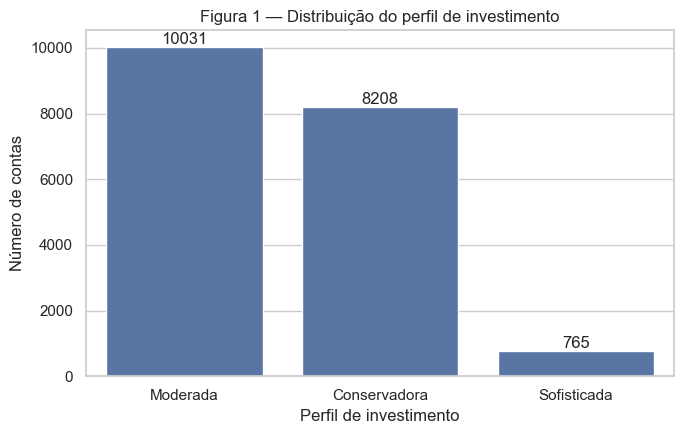

In [22]:
# Figura 1
plt.figure(
    figsize=(7, 4.5)
)

ordem_target = (
    target_table.index
)

ax = sns.countplot(
    data=df,
    x=target,
    order=ordem_target,
)

plt.title(
    "Figura 1 — Distribuição do perfil de investimento"
)

plt.xlabel(
    "Perfil de investimento"
)

plt.ylabel(
    "Número de contas"
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 1D. Separação treino/teste

O dataset será dividido em:

- 80% treino;
- 20% teste.

Será utilizado:

`random_state=42`

e estratificação pelo alvo para preservar aproximadamente as proporções das classes.

A partir deste ponto, decisões e estatísticas utilizadas no pré-processamento serão calculadas somente a partir do conjunto de treino.

In [23]:
X = (
    df[
        feature_cols
    ]
    .copy()
)

y = (
    df[
        target
    ]
    .copy()
)

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)

print(
    "Treino:",
    X_train.shape
)

print(
    "Teste:",
    X_test.shape
)

Treino: (15203, 15)
Teste: (3801, 15)


# 2. Análise univariada

A partir desta etapa, as análises utilizadas para orientar o pré-processamento serão feitas utilizando o conjunto de treino.

## 2A. Variáveis numéricas

Para todas as features numéricas serão calculados:

- média;
- mediana;
- desvio padrão;
- mínimo;
- primeiro quartil;
- segundo quartil;
- terceiro quartil;
- máximo;
- assimetria;
- percentual de zeros.

O percentual de zeros é especialmente importante neste dataset, pois um bucket com zero normalmente indica que o cliente não possui investimento naquela categoria.

In [24]:
numeric_summary = (
    X_train[
        numeric_features
    ]
    .describe()
    .T
)

numeric_summary[
    "mediana"
] = (
    X_train[
        numeric_features
    ]
    .median()
)

numeric_summary[
    "assimetria"
] = (
    X_train[
        numeric_features
    ]
    .skew()
)

numeric_summary[
    "zeros_%"
] = (
    X_train[
        numeric_features
    ]
    .eq(0)
    .mean()
    * 100
)

display(
    numeric_summary.round(3)
)

,count,mean,std,min,25%,50%,75%,max,mediana,assimetria,zeros_%
pct_stocks,15203.0,7.152,20.098,0.0,0.0,0.00,0.03,100.0,0.00,3.328,74.821
pct_fixed_income,15203.0,20.014,30.750,0.0,0.0,0.00,34.20,100.0,0.00,1.400,57.568
pct_repo,15203.0,0.099,2.419,0.0,0.0,0.00,0.00,100.0,0.00,34.521,99.309
pct_investment_fund,15203.0,24.469,34.162,0.0,0.0,0.92,44.20,100.0,0.92,1.169,46.044
pct_cash,15203.0,7.294,23.368,0.0,0.0,0.00,0.67,100.0,0.00,3.477,50.128
pct_options,15203.0,0.053,1.073,0.0,0.0,0.00,0.00,40.4,0.00,29.268,98.744
pct_treasure,15203.0,3.699,14.615,0.0,0.0,0.00,0.00,100.0,0.00,4.871,87.259
pct_private_pension,15203.0,5.202,18.402,0.0,0.0,0.00,0.00,100.0,0.00,4.000,88.094
pct_term,15203.0,0.019,0.592,0.0,0.0,0.00,0.00,24.8,0.00,33.734,99.855
pct_coe,15203.0,1.679,9.059,0.0,0.0,0.00,0.00,100.0,0.00,8.352,89.686


In [25]:
# Para evitar excesso de gráficos,
# selecionamos as 5 features percentuais
# com maior variância no treino.

available_percentage_features = [
    coluna
    for coluna
    in percentage_features
    if coluna
    in numeric_features
]

plot_pct_cols = (
    X_train[
        available_percentage_features
    ]
    .var()
    .sort_values(
        ascending=False
    )
    .head(5)
    .index
    .tolist()
)

print(
    "Features mostradas:",
    plot_pct_cols
)

Features mostradas: ['pct_investment_fund', 'pct_fixed_income', 'pct_cash', 'pct_stocks', 'pct_private_pension']


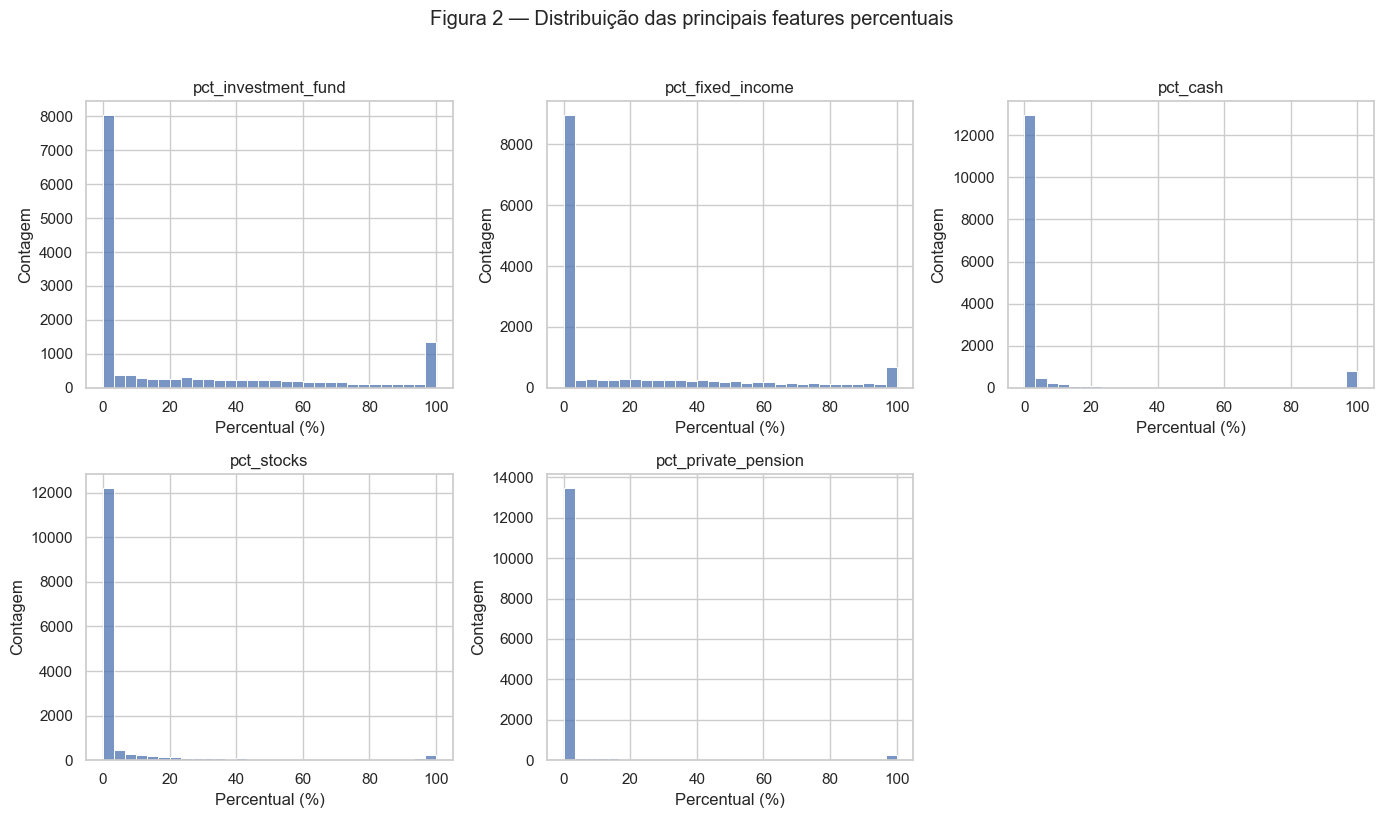

In [26]:
# Figura 2
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.ravel()

for ax, coluna in zip(
    axes,
    plot_pct_cols,
):
    sns.histplot(
        X_train[
            coluna
        ],
        bins=30,
        ax=ax,
    )

    ax.set_title(
        coluna
    )

    ax.set_xlabel(
        "Percentual (%)"
    )

    ax.set_ylabel(
        "Contagem"
    )

for ax in axes[len(plot_pct_cols):]:
    ax.set_visible(False)

fig.suptitle(
    "Figura 2 — Distribuição das principais features percentuais",
    y=1.02,
)

plt.tight_layout()
plt.show()

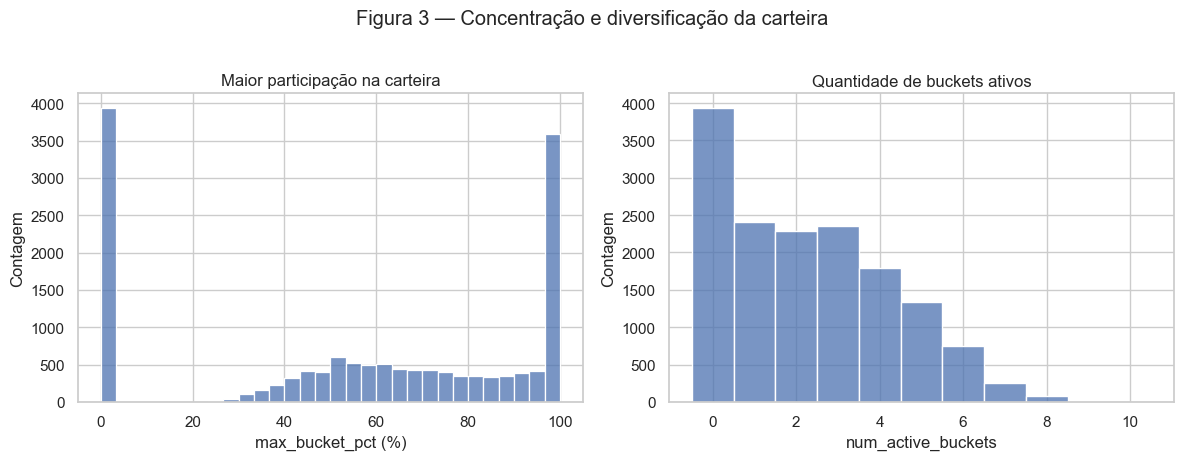

In [27]:
# Figura 3
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

sns.histplot(
    X_train[
        "max_bucket_pct"
    ],
    bins=30,
    ax=axes[0],
)

axes[0].set_title(
    "Maior participação na carteira"
)

axes[0].set_xlabel(
    "max_bucket_pct (%)"
)

axes[0].set_ylabel(
    "Contagem"
)

sns.histplot(
    X_train[
        "num_active_buckets"
    ],
    discrete=True,
    ax=axes[1],
)

axes[1].set_title(
    "Quantidade de buckets ativos"
)

axes[1].set_xlabel(
    "num_active_buckets"
)

axes[1].set_ylabel(
    "Contagem"
)

fig.suptitle(
    "Figura 3 — Concentração e diversificação da carteira",
    y=1.02,
)

plt.tight_layout()
plt.show()

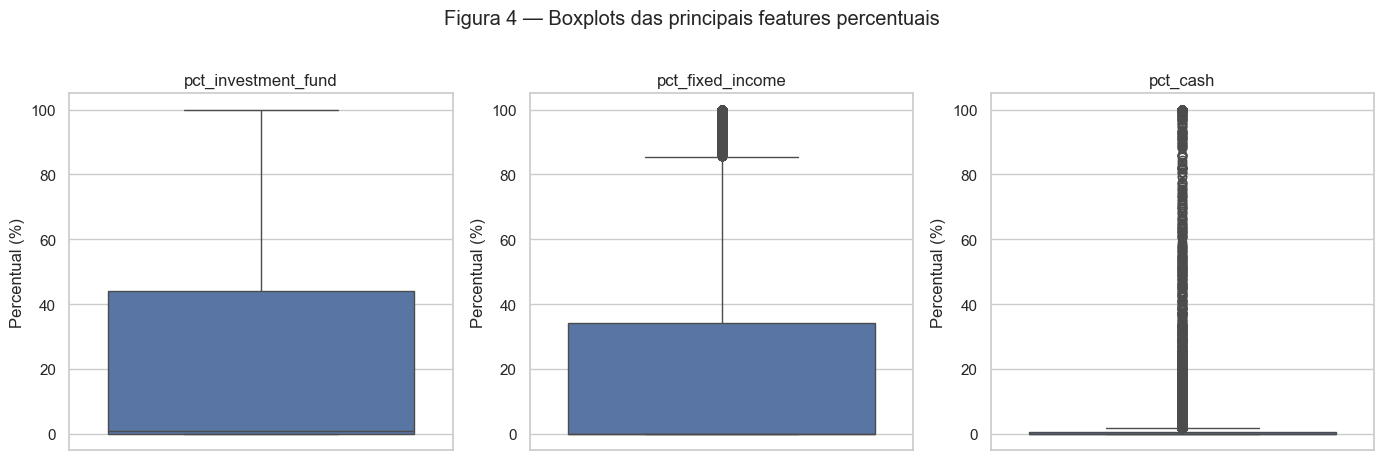

In [28]:
# Figura 4
box_cols = (
    plot_pct_cols[:3]
)

fig, axes = plt.subplots(
    1,
    len(box_cols),
    figsize=(14, 4.5),
)

if len(box_cols) == 1:
    axes = [axes]

for ax, coluna in zip(
    axes,
    box_cols,
):
    sns.boxplot(
        y=X_train[
            coluna
        ],
        ax=ax,
    )

    ax.set_title(
        coluna
    )

    ax.set_ylabel(
        "Percentual (%)"
    )

fig.suptitle(
    "Figura 4 — Boxplots das principais features percentuais",
    y=1.02,
)

plt.tight_layout()
plt.show()

## 2B. Variáveis categóricas

Para cada variável categórica serão avaliados:

- frequência das categorias;
- percentual de cada categoria;
- cardinalidade;
- presença de categorias raras.

Neste projeto, a principal variável categórica é `personType`.

In [29]:
categorical_rows = []

for coluna in categorical_features:
    frequencias = (
        X_train[
            coluna
        ]
        .value_counts(
            dropna=False
        )
    )

    for categoria, n in frequencias.items():
        categorical_rows.append({
            "feature": coluna,
            "categoria": categoria,
            "n": int(n),
            "percentual":
                100
                * n
                / len(X_train),
        })

categorical_summary = pd.DataFrame(
    categorical_rows
)

display(
    categorical_summary.round(2)
)

,feature,categoria,n,percentual
0,personType,F,14470,95.18
1,personType,J,726,4.78
2,personType,NaN,7,0.05


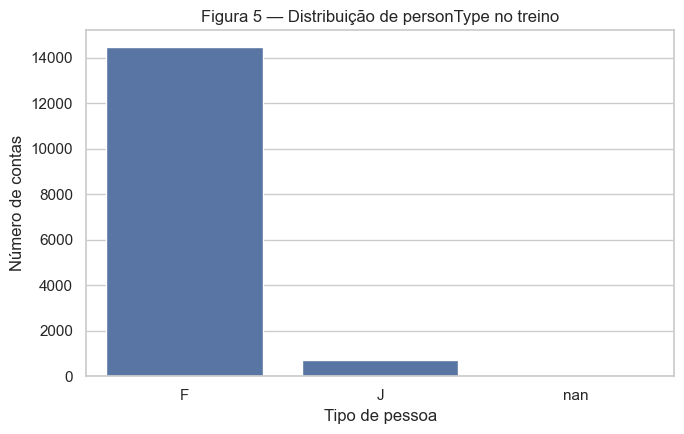

In [30]:
# Figura 5
if "personType" in categorical_features:
    plt.figure(
        figsize=(7, 4.5)
    )

    ordem_person = (
        X_train[
            "personType"
        ]
        .value_counts(
            dropna=False
        )
        .index
    )

    sns.countplot(
        data=X_train,
        x="personType",
        order=ordem_person,
    )

    plt.title(
        "Figura 5 — Distribuição de personType no treino"
    )

    plt.xlabel(
        "Tipo de pessoa"
    )

    plt.ylabel(
        "Número de contas"
    )

    plt.tight_layout()
    plt.show()

# 3. Análise bivariada e multivariada

In [31]:
train_eda = (
    X_train.copy()
)

train_eda[
    target
] = (
    y_train.values
)

## 3A. Numérica × numérica

Será utilizada **correlação de Spearman**.

A escolha se deve às características das features:

- grande quantidade de zeros;
- limites naturais entre 0% e 100%;
- distribuições assimétricas;
- relações que não precisam ser lineares;
- ausência da necessidade de normalidade.

In [32]:
corr = (
    X_train[
        numeric_features
    ]
    .corr(
        method="spearman"
    )
)

corr_abs = (
    corr.abs().copy()
)

np.fill_diagonal(
    corr_abs.values,
    np.nan,
)

correlation_pairs = (
    corr_abs
    .stack()
    .sort_values(
        ascending=False
    )
)

top_pair = (
    correlation_pairs.index[0]
)

top_corr_value = (
    correlation_pairs.iloc[0]
)

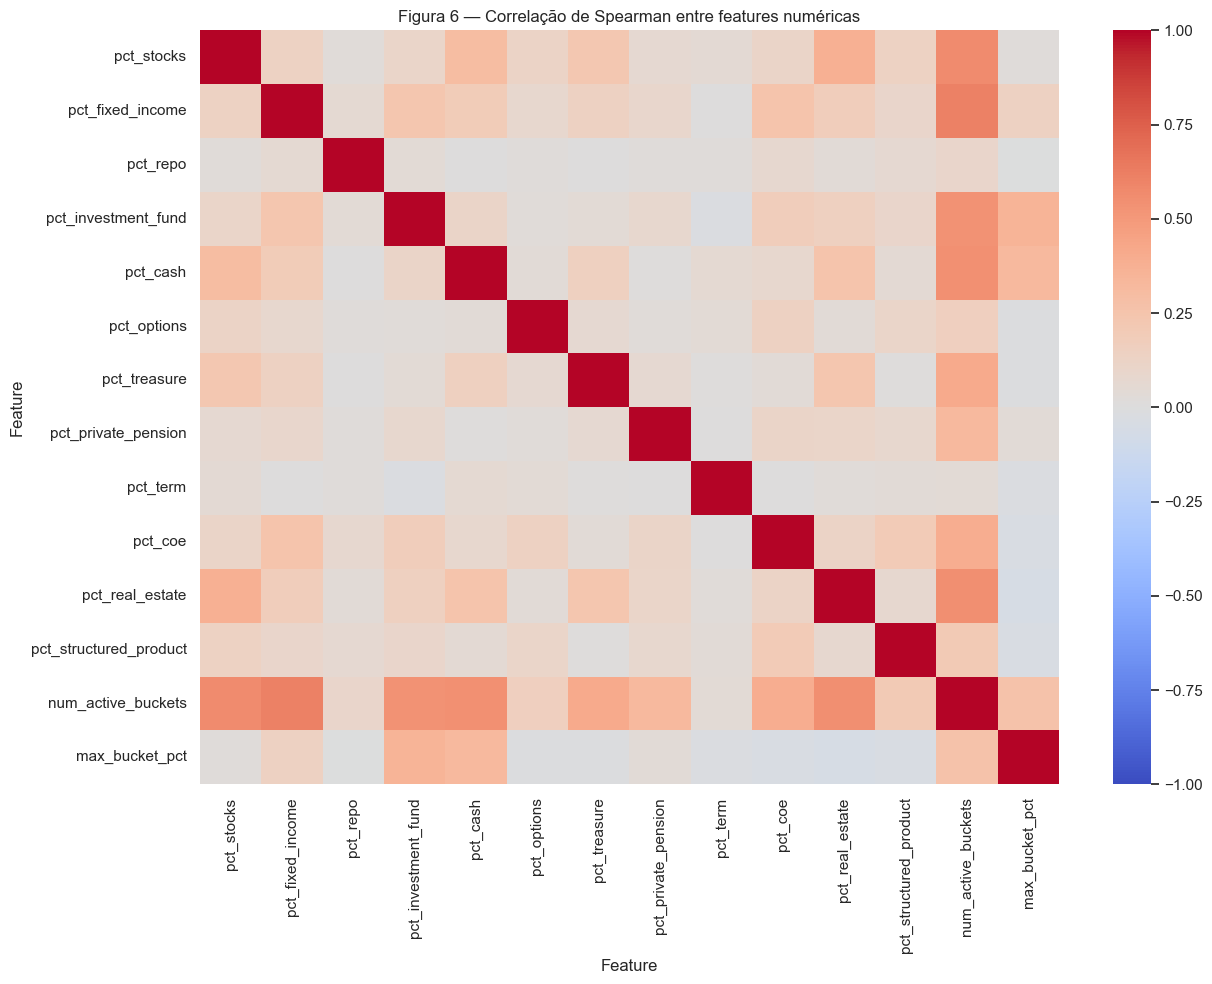

Conclusão: o par com maior correlação absoluta é pct_fixed_income × num_active_buckets, com |rho| = 0.615.


In [33]:
# Figura 6
plt.figure(
    figsize=(13, 10)
)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title(
    "Figura 6 — Correlação de Spearman entre features numéricas"
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

print(
    f"Conclusão: o par com maior correlação absoluta é "
    f"{top_pair[0]} × {top_pair[1]}, "
    f"com |rho| = {top_corr_value:.3f}."
)

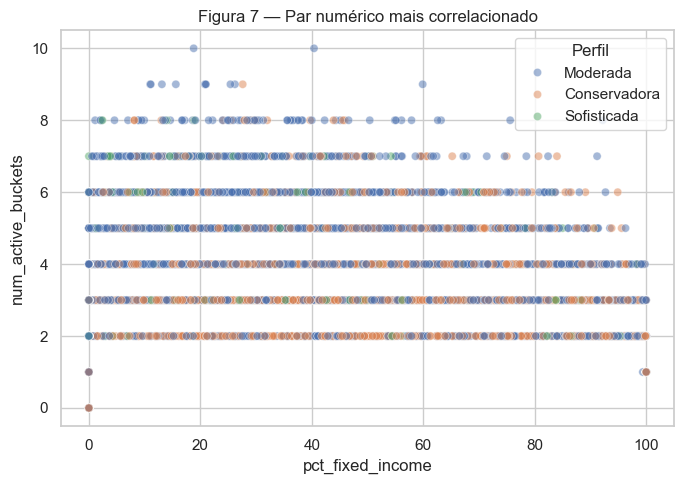

In [34]:
# Figura 7
plt.figure(
    figsize=(7, 5)
)

sns.scatterplot(
    data=train_eda,
    x=top_pair[0],
    y=top_pair[1],
    hue=target,
    alpha=0.5,
    s=35,
)

plt.title(
    "Figura 7 — Par numérico mais correlacionado"
)

plt.xlabel(
    top_pair[0]
)

plt.ylabel(
    top_pair[1]
)

plt.legend(
    title="Perfil"
)

plt.tight_layout()
plt.show()

## 3B. Categórica × alvo

Para classificação, serão comparadas as proporções das classes do alvo dentro das categorias de `personType`.

In [35]:
if "personType" in categorical_features:
    cat_target = (
        pd.crosstab(
            train_eda[
                "personType"
            ],
            train_eda[
                target
            ],
            normalize="index",
        )
        * 100
    )

    display(
        cat_target.round(2)
    )

investmentPolicy,Conservadora,Moderada,Sofisticada
personType,,,
F,43.06,53.00,3.94
J,45.73,48.48,5.79


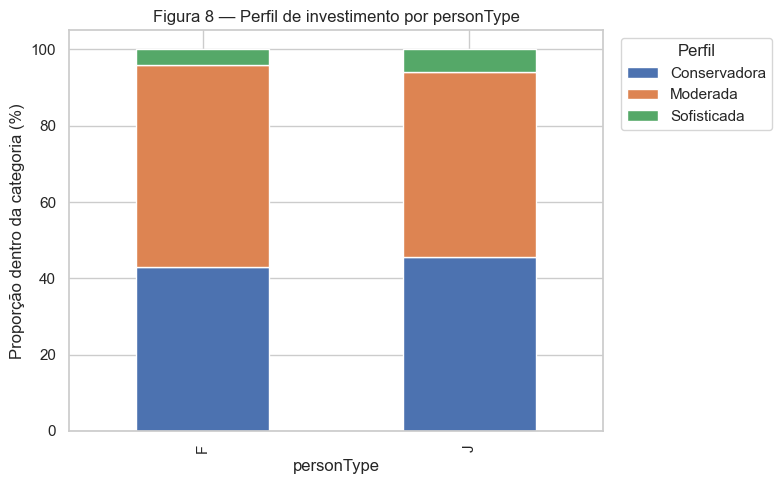

Conclusão: a maior diferença de proporção entre categorias de personType ocorre na classe Moderada, com amplitude de 4.51 pontos percentuais.


In [36]:
# Figura 8
if "personType" in categorical_features:
    cat_target.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5),
    )

    plt.title(
        "Figura 8 — Perfil de investimento por personType"
    )

    plt.xlabel(
        "personType"
    )

    plt.ylabel(
        "Proporção dentro da categoria (%)"
    )

    plt.legend(
        title="Perfil",
        bbox_to_anchor=(
            1.02,
            1,
        ),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

    if len(cat_target) >= 2:
        amplitude = (
            cat_target.max(
                axis=0
            )
            -
            cat_target.min(
                axis=0
            )
        ).sort_values(
            ascending=False
        )

        print(
            f"Conclusão: a maior diferença de proporção "
            f"entre categorias de personType ocorre na classe "
            f"{amplitude.index[0]}, com amplitude de "
            f"{amplitude.iloc[0]:.2f} pontos percentuais."
        )

## 3C. Numérica × categórica

Serão utilizadas as features `max_bucket_pct` e `num_active_buckets` para comparar localização e dispersão entre os grupos de `personType`.

A comparação será feita por:

- média;
- mediana;
- desvio padrão;
- boxplots.

In [37]:
if "personType" in categorical_features:
    grouped_numeric = (
        train_eda
        .groupby(
            "personType",
            dropna=False,
        )
        [
            [
                "max_bucket_pct",
                "num_active_buckets",
            ]
        ]
        .agg(
            [
                "mean",
                "median",
                "std",
                "count",
            ]
        )
    )

    display(
        grouped_numeric.round(3)
    )

max_bucket_pct                       num_active_buckets         \
                     mean median     std  count               mean median   
personType                                                                  
F                  56.430   62.2  37.849  14470              2.339    2.0   
J                  52.594   64.5  43.561    726              1.386    1.0   
NaN                76.200   73.2  14.500      7              3.000    3.0   

                          
              std  count  
personType                
F           1.999  14470  
J           1.433    726  
NaN         1.000      7

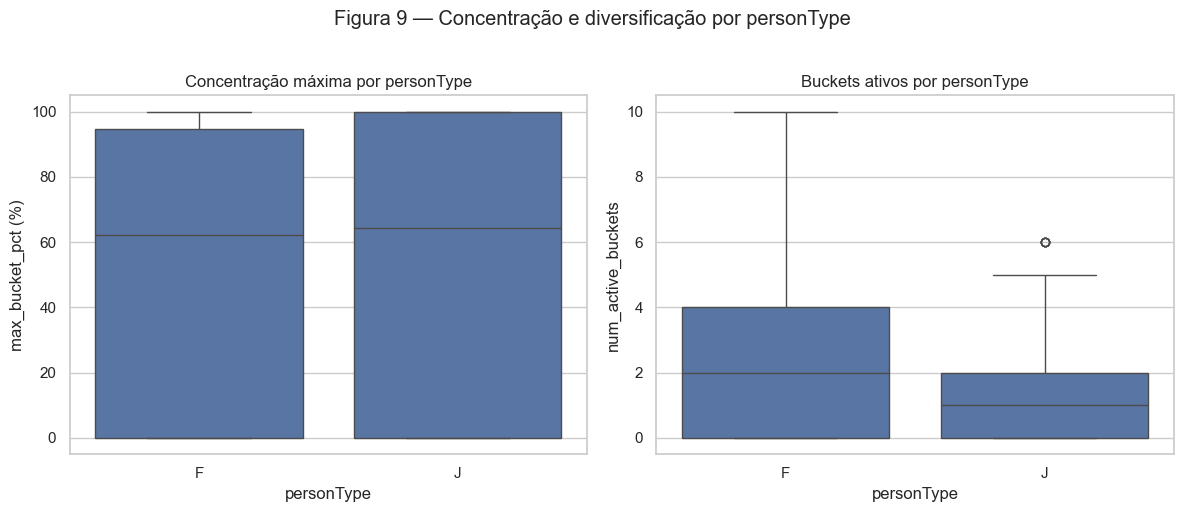

In [38]:
# Figura 9
if "personType" in categorical_features:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
    )

    sns.boxplot(
        data=train_eda,
        x="personType",
        y="max_bucket_pct",
        ax=axes[0],
    )

    axes[0].set_title(
        "Concentração máxima por personType"
    )

    axes[0].set_xlabel(
        "personType"
    )

    axes[0].set_ylabel(
        "max_bucket_pct (%)"
    )

    sns.boxplot(
        data=train_eda,
        x="personType",
        y="num_active_buckets",
        ax=axes[1],
    )

    axes[1].set_title(
        "Buckets ativos por personType"
    )

    axes[1].set_xlabel(
        "personType"
    )

    axes[1].set_ylabel(
        "num_active_buckets"
    )

    fig.suptitle(
        "Figura 9 — Concentração e diversificação por personType",
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

# 4. Pré-processamento

## 4A. Estratégias

As estratégias adotadas serão:

### Valores faltantes

Features numéricas:

`SimpleImputer(strategy="median")`

A mediana é menos sensível a valores extremos do que a média.

Features categóricas:

`SimpleImputer(strategy="most_frequent")`

### Outliers

As features de composição representam percentuais entre 0 e 100.

Uma carteira com 90% ou 100% em um único tipo de ativo pode representar uma situação real. Portanto, valores extremos válidos não serão removidos apenas pela regra do IQR.

O IQR será utilizado como ferramenta de diagnóstico.

### Encoding

Para `personType` será utilizado:

`OneHotEncoder(handle_unknown="ignore")`

O parâmetro `handle_unknown="ignore"` impede erros caso o conjunto de teste possua uma categoria que não apareceu no treino.

### Escalonamento

Será utilizado:

`StandardScaler()`

O escalonamento será importante para:

- PCA;
- t-SNE;
- UMAP;
- futura rede neural.

Todo o pré-processamento será ajustado somente sobre o conjunto de treino.

In [39]:
iqr_rows = []

for coluna in numeric_features:
    serie = (
        X_train[
            coluna
        ]
        .dropna()
    )

    q1 = serie.quantile(
        0.25
    )

    q3 = serie.quantile(
        0.75
    )

    iqr = (
        q3 - q1
    )

    limite_inferior = (
        q1
        - 1.5 * iqr
    )

    limite_superior = (
        q3
        + 1.5 * iqr
    )

    fora_iqr = (
        (serie < limite_inferior)
        |
        (serie > limite_superior)
    )

    iqr_rows.append({
        "feature": coluna,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_fora_iqr": int(
            fora_iqr.sum()
        ),
        "percentual_fora_iqr":
            fora_iqr.mean()
            * 100,
    })

iqr_summary = (
    pd.DataFrame(
        iqr_rows
    )
    .sort_values(
        "percentual_fora_iqr",
        ascending=False,
    )
)

display(
    iqr_summary.round(3)
)

,feature,q1,q3,iqr,limite_inferior,limite_superior,n_fora_iqr,percentual_fora_iqr
0,pct_stocks,0.0,0.03,0.03,-0.045,0.075,3768,24.785
10,pct_real_estate,0.0,0.00,0.00,0.000,0.000,2882,18.957
4,pct_cash,0.0,0.67,0.67,-1.005,1.675,2833,18.634
6,pct_treasure,0.0,0.00,0.00,0.000,0.000,1937,12.741
7,pct_private_pension,0.0,0.00,0.00,0.000,0.000,1810,11.906
9,pct_coe,0.0,0.00,0.00,0.000,0.000,1568,10.314
1,pct_fixed_income,0.0,34.20,34.20,-51.300,85.500,1113,7.321
11,pct_structured_product,0.0,0.00,0.00,0.000,0.000,290,1.908
5,pct_options,0.0,0.00,0.00,0.000,0.000,191,1.256
2,pct_repo,0.0,0.00,0.00,0.000,0.000,105,0.691


In [40]:
# Estratégia adotada:
# preservar valores extremos válidos.

outlier_rows_affected = 0

print(
    "Linhas removidas ou alteradas pela estratégia de outliers:",
    outlier_rows_affected,
)

Linhas removidas ou alteradas pela estratégia de outliers: 0


## 4C. Pipeline de pré-processamento

Será utilizado `ColumnTransformer` para aplicar transformações diferentes a features numéricas e categóricas.

### Pipeline numérico

1. imputação pela mediana;
2. `StandardScaler`.

### Pipeline categórico

1. imputação pela categoria mais frequente;
2. One-Hot Encoding.

O pipeline será ajustado exclusivamente em `X_train`.

`X_test` receberá somente `transform`.

In [41]:
def build_preprocessor(
    numeric_features,
    categorical_features,
):
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features,
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features,
            ),
        ]
    )

    return preprocessor

In [42]:
preprocess = build_preprocessor(
    numeric_features,
    categorical_features,
)

# FIT exclusivamente no treino.
X_train_t = (
    preprocess.fit_transform(
        X_train
    )
)

# Teste recebe apenas transform.
X_test_t = (
    preprocess.transform(
        X_test
    )
)

feature_names = (
    preprocess
    .get_feature_names_out()
)

print(
    "Shape treino original:",
    X_train.shape
)

print(
    "Shape treino transformado:",
    X_train_t.shape
)

print(
    "Shape teste transformado:",
    X_test_t.shape
)

Shape treino original: (15203, 15)
Shape treino transformado: (15203, 16)
Shape teste transformado: (3801, 16)


In [43]:
feature_names_table = pd.DataFrame({
    "feature_final":
        feature_names
})

display(
    feature_names_table
)

print(
    "Número de features depois do pipeline:",
    len(
        feature_names
    )
)

,feature_final
0,num__pct_stocks
1,num__pct_fixed_income
2,num__pct_repo
3,num__pct_investment_fund
4,num__pct_cash
5,num__pct_options
6,num__pct_treasure
7,num__pct_private_pension
8,num__pct_term
9,num__pct_coe


Número de features depois do pipeline: 16


## 4B. Redução de dimensionalidade

Serão comparados:

1. PCA;
2. t-SNE;
3. UMAP.

Todas as técnicas receberão os dados do **treino após o pré-processamento**.

Para t-SNE e UMAP será utilizada uma amostra de até 5.000 observações para reduzir o custo computacional.

O alvo será utilizado somente para colorir os pontos, e não fará parte das features.

### PCA

Além da projeção bidimensional, serão analisados:

- variância explicada acumulada;
- variância explicada por PC1 + PC2;
- loadings de PC1;
- loadings de PC2.

In [45]:
pca = PCA(
    random_state=RANDOM_STATE
)

X_pca = (
    pca.fit_transform(
        X_train_t
    )
)

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

pc12_variance = (
    pca
    .explained_variance_ratio_[
        :2
    ]
    .sum()
    * 100
)

print(
    f"Variância explicada por PC1 + PC2: "
    f"{pc12_variance:.2f}%"
)

Variância explicada por PC1 + PC2: 22.53%


In [46]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_names,
    columns=[
        "PC1",
        "PC2",
    ],
)

for componente in [
    "PC1",
    "PC2",
]:
    print(
        f"\nPrincipais loadings de {componente}:"
    )

    tabela_loading = (
        loadings
        .assign(
            abs_loading=
                loadings[
                    componente
                ].abs()
        )
        .sort_values(
            "abs_loading",
            ascending=False,
        )
        .head(10)
    )

    display(
        tabela_loading.round(4)
    )


Principais loadings de PC1:


,PC1,PC2,abs_loading
num__num_active_buckets,0.6068,-0.2326,0.6068
num__max_bucket_pct,0.5550,0.3120,0.5550
num__pct_fixed_income,0.3681,0.0425,0.3681
num__pct_investment_fund,0.2961,0.5382,0.2961
num__pct_real_estate,0.1707,-0.4083,0.1707
num__pct_stocks,0.1520,-0.4306,0.1520
num__pct_treasure,0.1285,-0.3154,0.1285
num__pct_coe,0.1012,0.0186,0.1012
num__pct_private_pension,0.0947,-0.0071,0.0947
num__pct_cash,-0.0741,0.2509,0.0741



Principais loadings de PC2:


,PC1,PC2,abs_loading
num__pct_investment_fund,0.2961,0.5382,0.5382
num__pct_stocks,0.1520,-0.4306,0.4306
num__pct_real_estate,0.1707,-0.4083,0.4083
num__pct_treasure,0.1285,-0.3154,0.3154
num__max_bucket_pct,0.5550,0.3120,0.3120
num__pct_cash,-0.0741,0.2509,0.2509
num__num_active_buckets,0.6068,-0.2326,0.2326
num__pct_options,0.0499,-0.1612,0.1612
num__pct_term,0.0120,-0.1003,0.1003
num__pct_structured_product,0.0642,-0.0729,0.0729


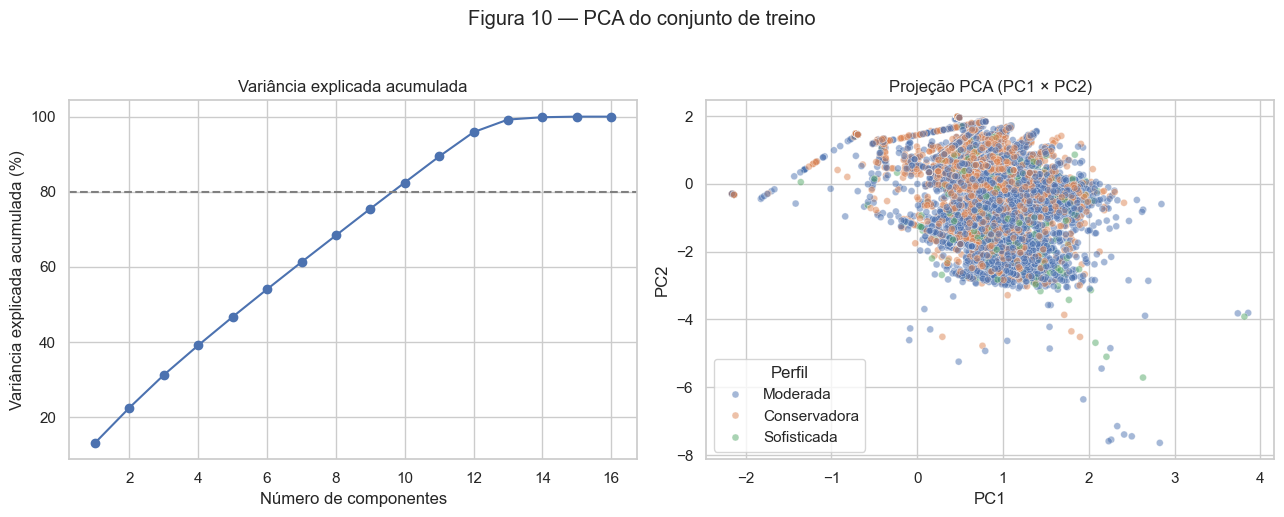

Conclusão: PC1 + PC2 explicam 22.53% da variância; são necessários 10 componentes para atingir 80%.


In [47]:
# Figura 10
pca_plot = pd.DataFrame({
    "PC1":
        X_pca[:, 0],
    "PC2":
        X_pca[:, 1],
    "perfil":
        y_train.to_numpy(),
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].plot(
    np.arange(
        1,
        len(
            cumulative_variance
        ) + 1,
    ),
    cumulative_variance * 100,
    marker="o",
)

axes[0].axhline(
    80,
    linestyle="--",
    color="gray",
)

axes[0].set_title(
    "Variância explicada acumulada"
)

axes[0].set_xlabel(
    "Número de componentes"
)

axes[0].set_ylabel(
    "Variância explicada acumulada (%)"
)

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="perfil",
    alpha=0.5,
    s=25,
    ax=axes[1],
)

axes[1].set_title(
    "Projeção PCA (PC1 × PC2)"
)

axes[1].set_xlabel(
    "PC1"
)

axes[1].set_ylabel(
    "PC2"
)

axes[1].legend(
    title="Perfil"
)

fig.suptitle(
    "Figura 10 — PCA do conjunto de treino",
    y=1.03,
)

plt.tight_layout()
plt.show()

n_components_80 = int(
    np.argmax(
        cumulative_variance >= 0.80
    )
) + 1

print(
    f"Conclusão: PC1 + PC2 explicam {pc12_variance:.2f}% "
    f"da variância; são necessários {n_components_80} "
    f"componentes para atingir 80%."
)

### Amostra para projeções não lineares

t-SNE e UMAP são computacionalmente mais caros.

Será utilizada uma amostra aleatória de no máximo 5.000 observações do treino com `random_state=42`.

In [48]:
rng = np.random.RandomState(
    RANDOM_STATE
)

sample_size = min(
    5000,
    len(
        X_train_t
    ),
)

sample_idx = rng.choice(
    len(
        X_train_t
    ),
    size=sample_size,
    replace=False,
)

X_sample = (
    X_train_t[
        sample_idx
    ]
)

y_sample = (
    y_train
    .to_numpy()[
        sample_idx
    ]
)

### t-SNE

Serão testados dois valores de perplexidade:

- `30`;
- `50`.

Não serão interpretados diretamente:

- tamanho dos grupos;
- distância absoluta entre clusters.

O objetivo é apenas verificar se estruturas locais semelhantes aparecem para diferentes parametrizações.

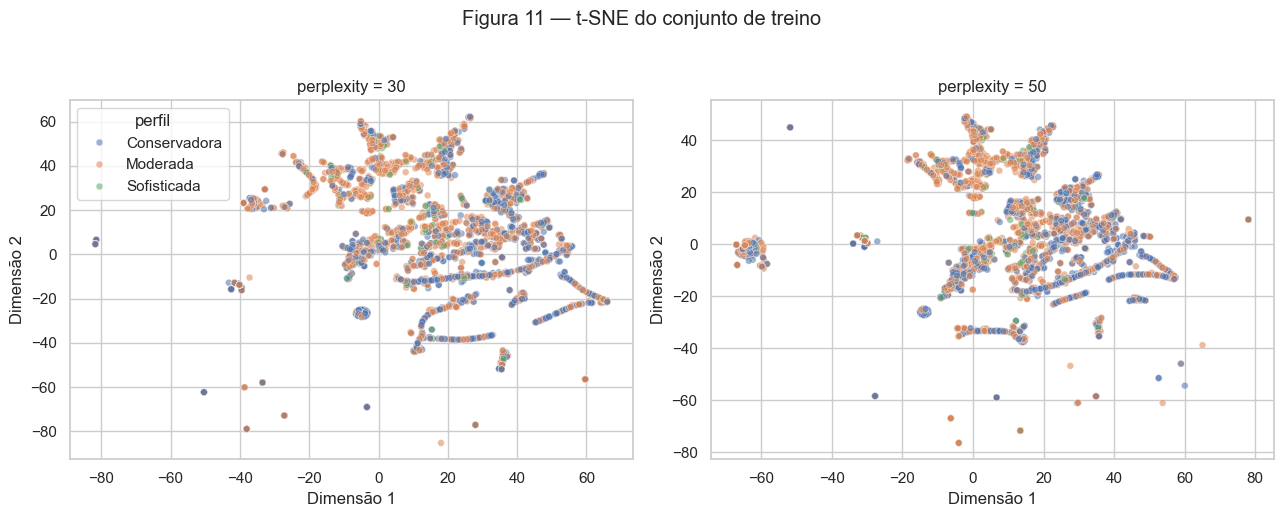

Conclusão: serão consideradas principalmente estruturas que persistam quando a perplexidade é alterada. A interpretação final deve ser escrita após observar a figura.


In [49]:
perplexities = [
    30,
    50,
]

tsne_results = {}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

for ax, perplexity in zip(
    axes,
    perplexities,
):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=RANDOM_STATE,
        init="pca",
        learning_rate="auto",
    )

    embedding = (
        tsne.fit_transform(
            X_sample
        )
    )

    tsne_results[
        perplexity
    ] = embedding

    plot_df = pd.DataFrame({
        "dim1":
            embedding[:, 0],
        "dim2":
            embedding[:, 1],
        "perfil":
            y_sample,
    })

    sns.scatterplot(
        data=plot_df,
        x="dim1",
        y="dim2",
        hue="perfil",
        alpha=0.55,
        s=24,
        ax=ax,
        legend=(
            ax is axes[0]
        ),
    )

    ax.set_title(
        f"perplexity = {perplexity}"
    )

    ax.set_xlabel(
        "Dimensão 1"
    )

    ax.set_ylabel(
        "Dimensão 2"
    )

fig.suptitle(
    "Figura 11 — t-SNE do conjunto de treino",
    y=1.03,
)

plt.tight_layout()
plt.show()

print(
    "Conclusão: serão consideradas principalmente estruturas "
    "que persistam quando a perplexidade é alterada. "
    "A interpretação final deve ser escrita após observar a figura."
)

### UMAP

Serão testados dois valores de `n_neighbors`:

- `15`;
- `50`.

Assim como no t-SNE, não serão interpretadas diretamente as distâncias ou tamanhos dos grupos.

In [50]:
# Caso ainda não esteja instalado no ambiente:
#
# %pip install umap-learn

In [51]:
try:
    import umap.umap_ as umap
except ImportError as erro:
    raise ImportError(
        "Instale o pacote com: %pip install umap-learn"
    ) from erro

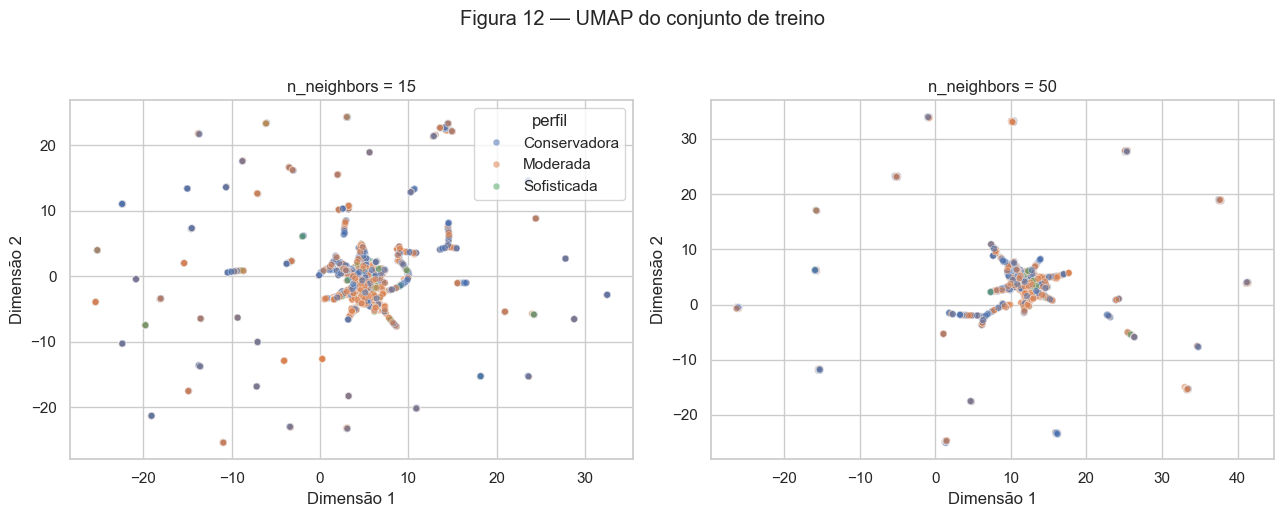

Conclusão: serão consideradas principalmente estruturas que persistam quando n_neighbors é alterado. A interpretação final deve ser escrita após observar a figura.


In [52]:
neighbors_values = [
    15,
    50,
]

umap_results = {}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

for ax, n_neighbors in zip(
    axes,
    neighbors_values,
):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        random_state=RANDOM_STATE,
    )

    embedding = (
        reducer.fit_transform(
            X_sample
        )
    )

    umap_results[
        n_neighbors
    ] = embedding

    plot_df = pd.DataFrame({
        "dim1":
            embedding[:, 0],
        "dim2":
            embedding[:, 1],
        "perfil":
            y_sample,
    })

    sns.scatterplot(
        data=plot_df,
        x="dim1",
        y="dim2",
        hue="perfil",
        alpha=0.55,
        s=24,
        ax=ax,
        legend=(
            ax is axes[0]
        ),
    )

    ax.set_title(
        f"n_neighbors = {n_neighbors}"
    )

    ax.set_xlabel(
        "Dimensão 1"
    )

    ax.set_ylabel(
        "Dimensão 2"
    )

fig.suptitle(
    "Figura 12 — UMAP do conjunto de treino",
    y=1.03,
)

plt.tight_layout()
plt.show()

print(
    "Conclusão: serão consideradas principalmente estruturas "
    "que persistam quando n_neighbors é alterado. "
    "A interpretação final deve ser escrita após observar a figura."
)

### Comparação entre PCA, t-SNE e UMAP

A PCA representa principalmente estruturas lineares presentes nos dados.

t-SNE e UMAP podem evidenciar estruturas locais e não lineares que não aparecem claramente na PCA.

A interpretação final desta seção deverá ser feita após observar as três figuras.

Devem ser respondidas as seguintes perguntas:

1. As classes apresentam separação clara na PCA?
2. Há grande sobreposição entre os perfis?
3. t-SNE apresenta estruturas locais que não aparecem na PCA?
4. Essas estruturas permanecem ao mudar a perplexidade?
5. UMAP apresenta estrutura semelhante para os dois valores de `n_neighbors`?
6. Os métodos não lineares revelam alguma separação que a PCA não mostra?

Não serão interpretadas diretamente distâncias ou tamanhos dos agrupamentos no t-SNE ou no UMAP.

# 5. Síntese para a futura modelagem

A etapa final resume as principais informações necessárias para quem dará continuidade ao projeto.

Os principais riscos investigados foram:

- desbalanceamento das classes;
- contas sem carteira observada;
- categorias cadastrais inconsistentes;
- presença de valores extremos;
- possíveis features constantes;
- risco de vazamento proveniente da policy;
- categorias não observadas no treino;
- necessidade de escalonamento antes da futura rede neural.

O pipeline resolve os valores faltantes, encoding e escala utilizando exclusivamente estatísticas aprendidas a partir do treino.

In [57]:

missing_model = (
    X
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    * 100
)

most_missing_col = (
    missing_model.index[0]
)

most_missing_pct = (
    missing_model.iloc[0]
)


discarded_columns = [
    "accountCode — identificador",
    "wallet_updated_at — metadado temporal",
    "wallet_ok — controle de qualidade",
    "pct_sum_selected — diagnóstico",
    "empty_wallet — diagnóstico",
    "dscSuitability — proximidade conceitual com o alvo",
    "campos derivados da policy — risco de vazamento",
]

if constant_features:

    discarded_columns.append(
        "features constantes: "
        + ", ".join(
            constant_features
        )
    )


summary_results = pd.DataFrame(
    [
        [
            1,
            "Dataset, tarefa e alvo",
            (
                "Wallet + Account + Policy | "
                "classificação multiclasse | "
                "investmentPolicy"
            ),
        ],

        [
            2,
            "Instâncias × features (numéricas / categóricas)",
            (
                f"{len(df)} × {len(feature_cols)} "
                f"({len(numeric_features)} numéricas / "
                f"{len(categorical_features)} categórica)"
            ),
        ],

        [
            3,
            "Coluna com mais faltantes e percentual",
            (
                f"{most_missing_col}: "
                f"{most_missing_pct:.2f}%"
            ),
        ],

        [
            4,
            "Colunas descartadas e motivo",
            "; ".join(
                discarded_columns
            ),
        ],

        [
            5,
            "Classe minoritária (%)",
            (
                f"{minority_class}: "
                f"{minority_pct:.2f}%"
            ),
        ],

        [
            6,
            "Tamanho do treino e teste",
            (
                f"treino = {len(X_train)} | "
                f"teste = {len(X_test)}"
            ),
        ],

        [
            7,
            "Par de numéricas mais correlacionado e valor",
            (
                f"{top_pair[0]} × "
                f"{top_pair[1]} | "
                f"Spearman rho = {top_corr_value:.4f}"
            ),
        ],

        [
            8,
            "Linhas afetadas pela estratégia de outliers",
            (
                f"{outlier_rows_affected} linhas"
            ),
        ],

        [
            9,
            "Variância explicada por PC1 + PC2",
            (
                f"{pc12_variance:.2f}%"
            ),
        ],

        [
            10,
            "Shape treino/teste após pipeline",
            (
                f"treino = {X_train_t.shape} | "
                f"teste = {X_test_t.shape}"
            ),
        ],
    ],

    columns=[
        "#",
        "Resumo dos resultados",
        "Valor",
    ],
)


display(
    summary_results
)

,#,Resumo dos resultados,Valor
0,1,"Dataset, tarefa e alvo",Wallet + Account + Policy | classificação mult...
1,2,Instâncias × features (numéricas / categóricas),19004 × 15 (14 numéricas / 1 categórica)
2,3,Coluna com mais faltantes e percentual,personType: 0.06%
3,4,Colunas descartadas e motivo,accountCode — identificador; wallet_updated_at...
4,5,Classe minoritária (%),Sofisticada: 4.03%
5,6,Tamanho do treino e teste,treino = 15203 | teste = 3801
6,7,Par de numéricas mais correlacionado e valor,pct_fixed_income × num_active_buckets | Spearm...
7,8,Linhas afetadas pela estratégia de outliers,0 linhas
8,9,Variância explicada por PC1 + PC2,22.53%
9,10,Shape treino/teste após pipeline,"treino = (15203, 16) | teste = (3801, 16)"
